In [1]:
from google.colab import drive
drive.mount('/content/drive')
# mounting the google drive

Mounted at /content/drive


In [2]:
# ==========================================
# CELL 1: Environment & Standard Library
# ==========================================
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# PyTorch Ecosystem
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.utils.class_weight import compute_class_weight

# Set device agnostic code (uses GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f" Computation device set to: {device}")

 Computation device set to: cpu


In [3]:


# 2. Define the path (ensure there are no accidental trailing spaces in your folder names)
mango_dir_dir = r"/content/drive/MyDrive/mango-disease-datasets /processed-512"
print(f"\nChecking contents of: {mango_dir_dir}\n")

# 3. List the contents exactly as they are structured
if os.path.exists(mango_dir_dir):
    print("Dataset root found! Here are the varieties and their subfolders:")
    varieties = sorted(os.listdir(mango_dir_dir))

    for variety in varieties:
        variety_path = os.path.join(mango_dir_dir, variety)
        # Verify it's a directory and not a rogue file (like .DS_Store)
        if os.path.isdir(variety_path):
            conditions = os.listdir(variety_path)
            print(f" - {variety}/ -> {conditions}")
else:
    print(f"Base dataset path does not exist. Double-check your Google Drive path: {mango_dir_dir}")


Checking contents of: /content/drive/MyDrive/mango-disease-datasets /processed-512

Dataset root found! Here are the varieties and their subfolders:
 - Amrapalli/ -> ['After Ripening', 'Before Ripening']
 - Arka Neelachal Kesari/ -> ['Before Ripening', 'After Ripening']
 - Banganpalli/ -> ['Before Ripening', 'After Ripening']
 - Dashehari/ -> ['After Ripening', 'Before Ripening']
 - Suvarnarekha/ -> ['After Ripening', 'Before Ripening']
 - Totapuri/ -> ['After Ripening', 'Before Ripening']


In [4]:
import os

# Assuming mango_dir_dir is still defined from Cell 1
# mango_dir_dir = r"/content/drive/MyDrive/mango-disease-datasets/processed-512"

if os.path.exists(mango_dir_dir):
    print(f"\nCounting files in each class directory within: {mango_dir_dir}")
    class_counts = {}
    total_images = 0

    # 1. Loop through the Variety folders
    for variety in sorted(os.listdir(mango_dir_dir)):
        variety_path = os.path.join(mango_dir_dir, variety)

        if os.path.isdir(variety_path):
            variety_total = 0
            condition_counts = {}

            # 2. Loop through the Condition folders (Before/After Ripening) inside each Variety
            for condition in sorted(os.listdir(variety_path)):
                condition_path = os.path.join(variety_path, condition)

                if os.path.isdir(condition_path):
                    # We standardized to .jpg in Phase 1, so we only need to look for that
                    num_files = len([name for name in os.listdir(condition_path) if name.lower().endswith('.jpg')])
                    condition_counts[condition] = num_files
                    variety_total += num_files

            class_counts[variety] = {
                'total': variety_total,
                'conditions': condition_counts
            }
            total_images += variety_total

    # 3. Print the results hierarchically
    print("-" * 50)
    for variety, data in class_counts.items():
        print(f" {variety}: {data['total']} total files")
        for condition, count in data['conditions'].items():
            print(f"   ↳ {condition}: {count} files")
    print("-" * 50)
    print(f"Total Dataset Images on Drive: {total_images}")

else:
    print(f"The directory '{mango_dir_dir}' does not exist. Please check your mount and path.")


Counting files in each class directory within: /content/drive/MyDrive/mango-disease-datasets /processed-512
--------------------------------------------------
 Amrapalli: 1218 total files
   ↳ After Ripening: 344 files
   ↳ Before Ripening: 874 files
 Arka Neelachal Kesari: 1198 total files
   ↳ After Ripening: 967 files
   ↳ Before Ripening: 231 files
 Banganpalli: 592 total files
   ↳ After Ripening: 166 files
   ↳ Before Ripening: 426 files
 Dashehari: 664 total files
   ↳ After Ripening: 306 files
   ↳ Before Ripening: 358 files
 Suvarnarekha: 1016 total files
   ↳ After Ripening: 675 files
   ↳ Before Ripening: 341 files
 Totapuri: 773 total files
   ↳ After Ripening: 135 files
   ↳ Before Ripening: 638 files
--------------------------------------------------
Total Dataset Images on Drive: 5461


In [5]:
import os
import shutil
from pathlib import Path
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

# 1. Define Paths
drive_dir = Path(mango_dir_dir)
local_dir = Path("/content/local_mango_data")

print("Gathering files from Google Drive...")
all_files = []
labels = []

# 2. Map every file to its Mango Variety
for img_path in drive_dir.rglob("*.jpg"):
    # variety is the parent of the parent (e.g., Amrapalli)
    variety = img_path.parent.parent.name
    all_files.append(img_path)
    labels.append(variety)

print(f"Found {len(all_files)} images.")

# 3. Stratified Split (70% Train, 15% Val, 15% Test)
# First split: 70% Train, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    all_files, labels, test_size=0.30, stratify=labels, random_state=42
)

# Second split: Divide the 30% Temporary perfectly in half (15% Val, 15% Test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print(f"Split distribution: Train({len(X_train)}), Val({len(X_val)}), Test({len(X_test)})")

# 4. Function to copy files into PyTorch-ready local folders
def copy_to_local(file_paths, split_name):
    print(f"\nCopying {split_name} split to local Colab runtime...")
    for img_path in tqdm(file_paths):
        variety = img_path.parent.parent.name

        # Create structure: /content/local_mango_data/train/Amrapalli/
        dest_folder = local_dir / split_name / variety
        dest_folder.mkdir(parents=True, exist_ok=True)

        # Copy the image file
        shutil.copy2(img_path, dest_folder / img_path.name)

# 5. Execute the transfer
copy_to_local(X_train, 'train')
copy_to_local(X_val, 'val')
copy_to_local(X_test, 'test')

print("\nSuccess! Data is securely split and ready for ultra-fast PyTorch training.")

Gathering files from Google Drive...
Found 5461 images.
Split distribution: Train(3822), Val(819), Test(820)

Copying train split to local Colab runtime...


  0%|          | 0/3822 [00:00<?, ?it/s]


Copying val split to local Colab runtime...


  0%|          | 0/819 [00:00<?, ?it/s]


Copying test split to local Colab runtime...


  0%|          | 0/820 [00:00<?, ?it/s]


Success! Data is securely split and ready for ultra-fast PyTorch training.


In [16]:
import os
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

# 2. Custom Drone Sensor Noise Transform
class AddGaussianNoise(object):
    """Simulates sensor noise on float tensors in range [0.0, 1.0]."""
    def __init__(self, std=0.03, p=0.3):
        self.std = std
        self.p = p

    def __call__(self, tensor):
        if torch.rand(1).item() < self.p:
            noise = torch.randn_like(tensor) * self.std
            return torch.clamp(tensor + noise, 0.0, 1.0)
        return tensor

# 3. Dimensions & Hyperparameters
batch_size = 32
img_height = 224
img_width = 224
local_mango_dir = "/content/local_mango_data"

# Standard ImageNet normalization parameters
norm_mean = [0.485, 0.456, 0.406]
norm_std = [0.229, 0.224, 0.225]

# 4. Transform Pipelines
data_transforms = {
    'train': v2.Compose([
        v2.Resize((img_height, img_width)),
        v2.RandomHorizontalFlip(p=0.5),
        v2.RandomVerticalFlip(p=0.5),
        v2.RandomRotation(degrees=45),
        v2.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
        v2.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True), # Scales uint8 [0, 255] to float32 [0.0, 1.0]
        AddGaussianNoise(std=0.03, p=0.3),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ]),
    'val': v2.Compose([
        v2.Resize((img_height, img_width)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ]),
    'test': v2.Compose([
        v2.Resize((img_height, img_width)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=norm_mean, std=norm_std)
    ])
}

# 5. Datasets & Loaders
splits = ['train', 'val', 'test']
image_datasets = {
    x: datasets.ImageFolder(os.path.join(local_mango_dir, x), transform=data_transforms[x])
    for x in splits
}

dataloaders = {
    x: DataLoader(
        image_datasets[x],
        batch_size=batch_size,
        shuffle=(x == 'train'), # Only shuffle training data
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )
    for x in splits
}

# 6. Verification
dataset_sizes = {x: len(image_datasets[x]) for x in splits}
class_names = image_datasets['train'].classes
num_classes = len(class_names)

print(f"\nClass labels ({num_classes} varieties): {class_names}")
for split in splits:
    print(f"✅ {split.capitalize()} images: {dataset_sizes[split]}")

Using compute device: cuda

Class labels (6 varieties): ['Amrapalli', 'Arka Neelachal Kesari', 'Banganpalli', 'Dashehari', 'Suvarnarekha', 'Totapuri']
✅ Train images: 3822
✅ Val images: 819
✅ Test images: 820


In [23]:
from typing import cast
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
from torchvision.models.feature_extraction import create_feature_extractor

# ==========================================
# 1. FOUNDATIONAL EDGE BLOCKS (UNCHANGED)
# ==========================================
class Routing(nn.Module):
    def __init__(self, in_channels, out_channels, dropout_rate=0.2, temperature=30):
        super().__init__()
        self.temperature = temperature
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc = nn.Linear(in_channels, out_channels)
        nn.init.kaiming_normal_(self.fc.weight, mode='fan_out', nonlinearity='relu')
        nn.init.constant_(self.fc.bias, 0.0)

    def forward(self, x):
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return F.softmax(self.fc(x) / self.temperature, dim=1)

class CondConv2D(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, kernel_size, stride=1, padding=1, bias: bool = True, num_experts: int = 3):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.kernel_size = (kernel_size, kernel_size) if isinstance(kernel_size, int) else tuple(kernel_size)
        self.stride = stride
        self.padding = padding
        self.use_bias = bias
        self.num_experts = num_experts
        self.routing = Routing(in_channels, out_channels=num_experts)

        self.convs = nn.ModuleList([
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding, bias=bias)
            for _ in range(num_experts)
        ])
        for conv in self.convs:
            nn.init.kaiming_normal_(conv.weight, mode='fan_out', nonlinearity='relu')
            if conv.bias is not None:
                nn.init.constant_(conv.bias, 0.0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape
        routing_weights = self.routing(x)
        expert_weights = torch.stack([cast(torch.Tensor, c.weight) for c in self.convs])
        expert_biases = torch.stack([cast(torch.Tensor, c.bias) for c in self.convs]) if self.use_bias else None

        mixed_weights = torch.einsum('be,eoikl->boikl', routing_weights, expert_weights)
        mixed_weights = mixed_weights.reshape(B * self.out_channels, C, self.kernel_size[0], self.kernel_size[1])
        x_reshaped = x.reshape(1, B * C, H, W)
        mixed_biases = torch.einsum('be,eo->bo', routing_weights, expert_biases).reshape(-1) if expert_biases is not None else None

        out = F.conv2d(x_reshaped, mixed_weights, bias=mixed_biases, stride=self.stride, padding=self.padding, groups=B)
        return out.reshape(B, self.out_channels, out.shape[2], out.shape[3])

class SeparableConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, bias=True):
        super().__init__()
        pad = kernel_size // 2 if isinstance(kernel_size, int) else (kernel_size[0] // 2, kernel_size[1] // 2)
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=kernel_size, stride=stride, padding=pad, groups=in_channels, bias=bias)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=bias)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))

class InceptionBlock(nn.Module):
    def __init__(self, in_channels, nb_filter):
        super().__init__()
        self.branch1x1 = SeparableConv2d(in_channels, nb_filter, kernel_size=1)
        self.branch3x3_base = SeparableConv2d(in_channels, nb_filter, kernel_size=1)
        self.branch3x3_1 = SeparableConv2d(nb_filter, nb_filter, kernel_size=(3, 1))
        self.branch3x3_2 = SeparableConv2d(nb_filter, nb_filter, kernel_size=(1, 3))
        self.branch5x5_base = SeparableConv2d(in_channels, nb_filter, kernel_size=1)
        self.branch5x5_1 = SeparableConv2d(nb_filter, nb_filter, kernel_size=(3, 1))
        self.branch5x5_2 = SeparableConv2d(nb_filter, nb_filter, kernel_size=(1, 3))
        self.branch5x5_final1 = SeparableConv2d(nb_filter, nb_filter, kernel_size=(3, 1))
        self.branch5x5_final2 = SeparableConv2d(nb_filter, nb_filter, kernel_size=(1, 3))
        self.branchpool_max = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.branchpool_conv = SeparableConv2d(in_channels, nb_filter, kernel_size=1)

    def forward(self, x):
        b1 = self.branch1x1(x)
        b3_b = self.branch3x3_base(x)
        b3 = self.branch3x3_1(b3_b) + self.branch3x3_2(b3_b)
        b5_b = self.branch5x5_base(x)
        b5_m = self.branch5x5_1(b5_b) + self.branch5x5_2(b5_b)
        b5 = self.branch5x5_final1(b5_m) + self.branch5x5_final2(b5_m)
        bp = self.branchpool_conv(self.branchpool_max(x))
        return torch.cat([b1, b3, b5, bp], dim=1)

class PatchTokenizer(nn.Module):
    def __init__(self, in_channels, patch_size, embed_dim, img_size):
        super().__init__()
        self.projection = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        num_patches = (img_size // patch_size) ** 2
        self.position_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))
        nn.init.trunc_normal_(self.position_embedding, std=0.02)

    def forward(self, x):
        return self.projection(x).flatten(2).transpose(1, 2) + self.position_embedding

class SSEBlock(nn.Module):
    def __init__(self, in_channels, ratio=4):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Linear(in_channels, in_channels // ratio)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(in_channels // ratio, in_channels)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.size()
        se = self.sigmoid(self.fc2(self.relu(self.fc1(self.avg_pool(x).view(b, c))))).view(b, c, 1, 1)
        se_out = x * se
        s_mean = torch.mean(x, dim=1, keepdim=True)
        s_std = torch.std(x, dim=1, keepdim=True)
        s_max = torch.max(x, dim=1, keepdim=True)[0]
        # Output channels = in_channels + 3
        return torch.cat([se_out, s_mean, s_std, s_max], dim=1)

# ==========================================
# 2. UPGRADED & DIMENSION-ALIGNED ARCHITECTURE
# ==========================================
class CondConViT_Large(nn.Module):
    def __init__(self, num_classes=6, dropout_rate=0.4):
        super().__init__()

        # --- 1. THE BACKBONE ---
        base_model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
        return_nodes = {'features.1': 'x1', 'features.3': 'x2', 'features.6': 'x_inc'}
        self.backbone = create_feature_extractor(base_model, return_nodes=return_nodes)

        # Unfreeze backbone
        for param in self.backbone.parameters():
            param.requires_grad = True

        # --- 2. MULTI-SCALE BRANCHES ---
        # Branch 1
        self.cond1_1 = CondConv2D(in_channels=16, out_channels=32, kernel_size=3, stride=2)
        self.cond1_2 = CondConv2D(in_channels=32, out_channels=64, kernel_size=3, stride=2)
        self.cond1_3 = CondConv2D(in_channels=64, out_channels=64, kernel_size=3, stride=2)
        self.conv1_final = nn.Conv2d(64, 128, kernel_size=4, stride=1, padding=0)
        self.sse1 = SSEBlock(in_channels=128, ratio=4) # Outputs 128 + 3 = 131 channels
        self.p1_proj = nn.Conv2d(131, 128, kernel_size=1) # Projects 131 -> 128

        # Branch 2
        self.cond2_1 = CondConv2D(in_channels=24, out_channels=32, kernel_size=3, stride=2)
        self.cond2_2 = CondConv2D(in_channels=32, out_channels=64, kernel_size=3, stride=2)
        self.conv2_final = nn.Conv2d(64, 128, kernel_size=4, stride=1, padding=0)
        self.sse2 = SSEBlock(in_channels=128, ratio=4) # Outputs 128 + 3 = 131 channels
        self.p2_proj = nn.Conv2d(131, 128, kernel_size=1) # Projects 131 -> 128

        # Branch 3 (Inception)
        self.inception = InceptionBlock(in_channels=32, nb_filter=64) # Outputs 4 * 64 = 256 channels
        self.cond3_1 = CondConv2D(in_channels=256, out_channels=128, kernel_size=3, stride=2)
        self.conv3_final = nn.Conv2d(128, 128, kernel_size=4, stride=1, padding=0)
        self.sse3 = SSEBlock(in_channels=128, ratio=4) # Outputs 128 + 3 = 131 channels
        self.p3_proj = nn.Conv2d(131, 128, kernel_size=1) # Projects 131 -> 128

        # --- 3. VISION TRANSFORMER ---
        self.tokenizer = PatchTokenizer(in_channels=256, patch_size=7, embed_dim=128, img_size=28)
        self.vit_dropout = nn.Dropout(dropout_rate)
        encoder_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4, dim_feedforward=256, dropout=dropout_rate, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.final_norm = nn.LayerNorm(128)
        self.vit_projection = nn.Conv2d(128, 128, kernel_size=1)

        # --- 4. FUSION & CLASSIFICATION ---
        self.fusion_sse = SSEBlock(in_channels=128, ratio=4) # Outputs 128 + 3 = 131 channels
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Linear(131, num_classes) # Correctly takes 131 input features

    def forward(self, x):
        features = self.backbone(x)
        x1, x2, x_inc = features['x1'], features['x2'], features['x_inc']

        # Branch 1
        p1 = self.p1_proj(self.sse1(self.conv1_final(self.cond1_3(self.cond1_2(self.cond1_1(x1))))))

        # Branch 2
        p2 = self.p2_proj(self.sse2(self.conv2_final(self.cond2_2(self.cond2_1(x2)))))

        # Branch 3
        inc_out = self.inception(x_inc)
        p3 = self.p3_proj(self.sse3(self.conv3_final(self.cond3_1(inc_out))))

        # ViT Branch
        tokens = self.tokenizer(inc_out)
        tokens = self.vit_dropout(tokens)
        vit_out = self.transformer(tokens)
        vit_out = self.final_norm(vit_out)

        b = vit_out.size(0)
        vit_spatial = vit_out.transpose(1, 2).view(b, 128, 4, 4)
        vit_spatial = F.interpolate(vit_spatial, size=(11, 11), mode='bilinear', align_corners=False)
        vit_spatial = self.vit_projection(vit_spatial)

        # Merge all branches (all are 128 channels at 11x11)
        merged = p1 + p2 + p3 + vit_spatial
        merged = self.fusion_sse(merged) # Becomes 131 channels

        out = self.global_pool(merged)
        out = torch.flatten(out, 1)

        return self.classifier(out)

# Instantiate
model = CondConViT_Large(num_classes=num_classes).to(device)
print(f"CondConViT_Large model successfully initialized on {device}.")

CondConViT_Large model successfully initialized on cuda.


/tmp/ipykernel_762/1035249260.py:170: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)


In [18]:
pip install torchinfo

In [24]:
# 1. Install torchinfo if running in a fresh Colab session
!pip install -q torchinfo

from torchinfo import summary

# 2. Ensure dimensions and device are set
img_height = 224
img_width = 224

# 3. Generate detailed summary
# Explicitly passing device=device ensures dummy input tensors match the model's device (CUDA/CPU)
summary(
    model,
    input_size=(1, 3, img_height, img_width),
    device=device,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    depth=3,
    row_settings=["var_names"]
)

Layer (type (var_name))                                 Input Shape               Output Shape              Param #                   Trainable
CondConViT_Large (CondConViT_Large)                     [1, 3, 224, 224]          [1, 6]                    --                        True
├─MobileNetV2 (backbone)                                [1, 3, 224, 224]          [1, 32, 28, 28]           --                        True
│    └─Module (features)                                --                        --                        --                        True
│    │    └─Conv2dNormActivation (0)                    [1, 3, 224, 224]          [1, 32, 112, 112]         928                       True
│    │    └─Module (1)                                  --                        --                        896                       True
│    │    └─Module (2)                                  --                        --                        5,136                     True
│    │    └─Module (3)

In [25]:
import numpy as np
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight

print("=" * 60)
print("COMPUTING BALANCED CLASS WEIGHTS (TRAINING SPLIT ONLY)")
print("=" * 60)

# Extract targets directly from the training ImageFolder
train_targets = np.array(image_datasets['train'].targets)
unique_classes = np.unique(train_targets)

# Compute balanced weights: n_samples / (n_classes * count_per_class)
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=train_targets
)

# Clip weights to prevent minor classes from skewing loss gradients excessively
clipped_weights = np.clip(raw_weights, a_min=0.5, a_max=1.75)

# Convert to torch tensor and transfer to active device
class_weights_tensor = torch.tensor(clipped_weights, dtype=torch.float32).to(device)

print(f"{'Class Name':<25} | {'Count (Train)':<14} | {'Weight':<10}")
print("-" * 55)
for idx, class_name in enumerate(class_names):
    count = np.sum(train_targets == idx)
    print(f"{class_name:<25} | {count:<14} | {clipped_weights[idx]:.4f}")

# Initialize CrossEntropyLoss with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print("\n✅ Loss function (CrossEntropyLoss) initialized with computed class weights.")

COMPUTING BALANCED CLASS WEIGHTS (TRAINING SPLIT ONLY)
Class Name                | Count (Train)  | Weight    
-------------------------------------------------------
Amrapalli                 | 852            | 0.7477
Arka Neelachal Kesari     | 839            | 0.7592
Banganpalli               | 414            | 1.5386
Dashehari                 | 465            | 1.3699
Suvarnarekha              | 711            | 0.8959
Totapuri                  | 541            | 1.1774

✅ Loss function (CrossEntropyLoss) initialized with computed class weights.


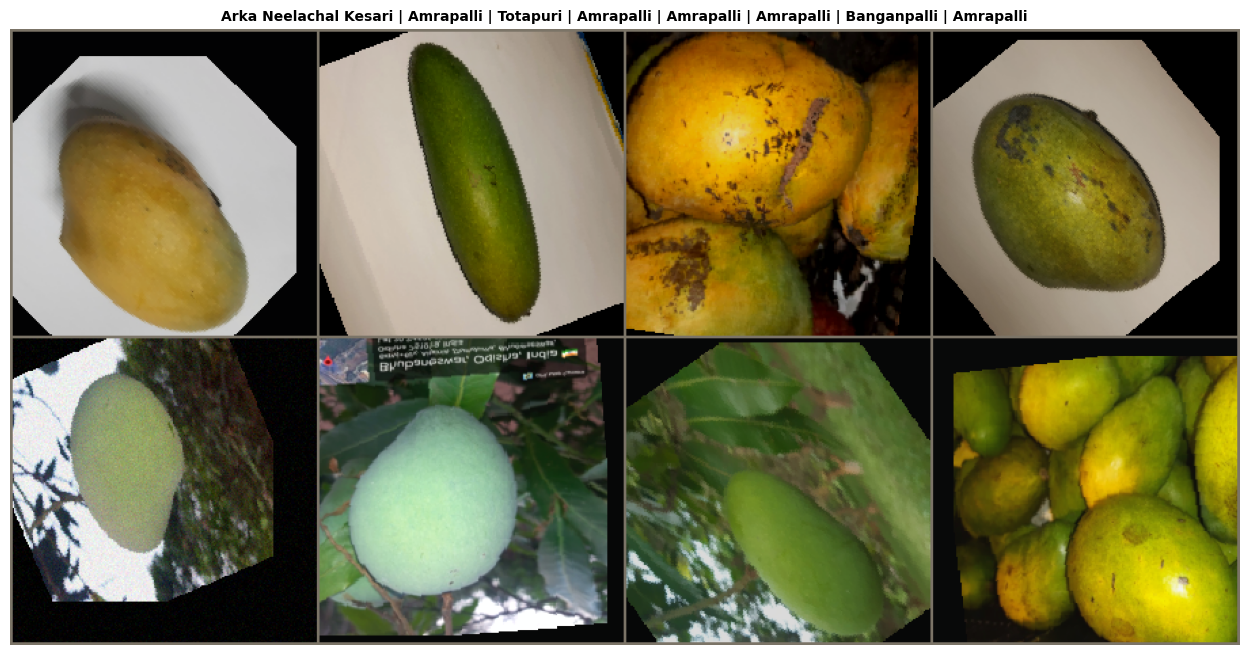

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

def imshow_unnormalized(inp, title=None):
    """Un-normalizes a PyTorch tensor and displays it as a matplotlib image."""
    # Convert from PyTorch tensor (C, H, W) to numpy array (H, W, C)
    inp = inp.numpy().transpose((1, 2, 0))

    # Reverse the ImageNet normalization math from Cell 1
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean

    # Clip values to ensure they remain between 0 and 1 for rendering
    inp = np.clip(inp, 0, 1)

    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=10, weight='bold')
    plt.axis('off')

# Grab one batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Slice the batch to only show the first 8 images so it fits cleanly on screen
num_images = 8
inputs_subset = inputs[:num_images]
classes_subset = classes[:num_images]

# Create a visual grid
out_grid = torchvision.utils.make_grid(inputs_subset, nrow=4, padding=2)

# Plot the grid
plt.figure(figsize=(16, 8))
# Map the integer labels back to the actual mango variety names
title_list = [class_names[x] for x in classes_subset]
imshow_unnormalized(out_grid, title=" | ".join(title_list))
plt.show()

In [27]:
import os
import time
import copy
from pathlib import Path
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch

EPOCHS = 100
WEIGHT_DECAY = 1e-2

drive_checkpoint_dir = Path("/content/drive/MyDrive/mango-disease-datasets/checkpoints")
drive_checkpoint_dir.mkdir(parents=True, exist_ok=True)
resume_checkpoint_path = drive_checkpoint_dir / "last_mango_variety_checkpoint_.pth"
best_model_path = drive_checkpoint_dir / "best_mango_variety_model_.pth"

# --- DIFFERENTIAL OPTIMIZER SETUP ---
backbone_params = []
head_params = []

for name, param in model.named_parameters():
    if 'backbone' in name:
        backbone_params.append(param)
    else:
        head_params.append(param)

optimizer = optim.AdamW([
    {'params': backbone_params, 'lr': 1e-5},  # Gentle fine-tuning for MobileNet
    {'params': head_params, 'lr': 1e-4}       # Normal learning rate for custom blocks
], weight_decay=WEIGHT_DECAY)

scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6)
scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

start_epoch = 0
best_val_loss = float('inf')

# --- RESUME LOGIC ---
if resume_checkpoint_path.exists():
    print(f"Found existing training state at: {resume_checkpoint_path}")
    checkpoint = torch.load(resume_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    if scaler and 'scaler_state_dict' in checkpoint:
        scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    print(f"--> Successfully resumed from Epoch {start_epoch}")

print("=" * 60)
print(f"STARTING TRAINING: Epoch {start_epoch + 1} to {EPOCHS} | BATCH SIZE: {batch_size}")
print("=" * 60)

start_time = time.time()

for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 30)

    # --- TRAINING PHASE ---
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for inputs, labels in dataloaders['train']:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()

        if scaler:
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in dataloaders['val']:
            inputs, labels = inputs.to(device), labels.to(device)
            if scaler:
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc * 100:.2f}%")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc * 100:.2f}%")

    scheduler.step(epoch_val_loss)

    # Save Resumable Checkpoint
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'scaler_state_dict': scaler.state_dict() if scaler else None,
        'best_val_loss': best_val_loss,
    }, resume_checkpoint_path)

    # Save Best Inference Model
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), best_model_path)
        print(f"--> Saved improved checkpoint to {best_model_path}")

elapsed = time.time() - start_time
print(f"\nTraining completed in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
print(f"Lowest Validation Loss: {best_val_loss:.4f}")

STARTING TRAINING: Epoch 1 to 100 | BATCH SIZE: 32

Epoch 1/100
------------------------------
Train Loss: 1.5157 | Train Acc: 38.96%
Val Loss:   1.3022 | Val Acc:   48.96%
--> Saved improved checkpoint to /content/drive/MyDrive/mango-disease-datasets/checkpoints/best_mango_variety_model_.pth

Epoch 2/100
------------------------------
Train Loss: 1.3203 | Train Acc: 48.82%
Val Loss:   1.2308 | Val Acc:   51.16%
--> Saved improved checkpoint to /content/drive/MyDrive/mango-disease-datasets/checkpoints/best_mango_variety_model_.pth

Epoch 3/100
------------------------------
Train Loss: 1.2118 | Train Acc: 53.79%
Val Loss:   1.1797 | Val Acc:   55.19%
--> Saved improved checkpoint to /content/drive/MyDrive/mango-disease-datasets/checkpoints/best_mango_variety_model_.pth

Epoch 4/100
------------------------------
Train Loss: 1.1557 | Train Acc: 56.07%
Val Loss:   1.0772 | Val Acc:   60.32%
--> Saved improved checkpoint to /content/drive/MyDrive/mango-disease-datasets/checkpoints/best_ma

EVALUATING BEST MODEL ON HELD-OUT TEST SET

Classification Report:
                       precision    recall  f1-score   support

            Amrapalli     0.7500    0.6230    0.6806       183
Arka Neelachal Kesari     0.7900    0.8778    0.8316       180
          Banganpalli     0.6733    0.7640    0.7158        89
            Dashehari     0.6220    0.7980    0.6991        99
         Suvarnarekha     0.9160    0.7124    0.8015       153
             Totapuri     0.8099    0.8448    0.8270       116

             accuracy                         0.7634       820
            macro avg     0.7602    0.7700    0.7593       820
         weighted avg     0.7744    0.7634    0.7631       820



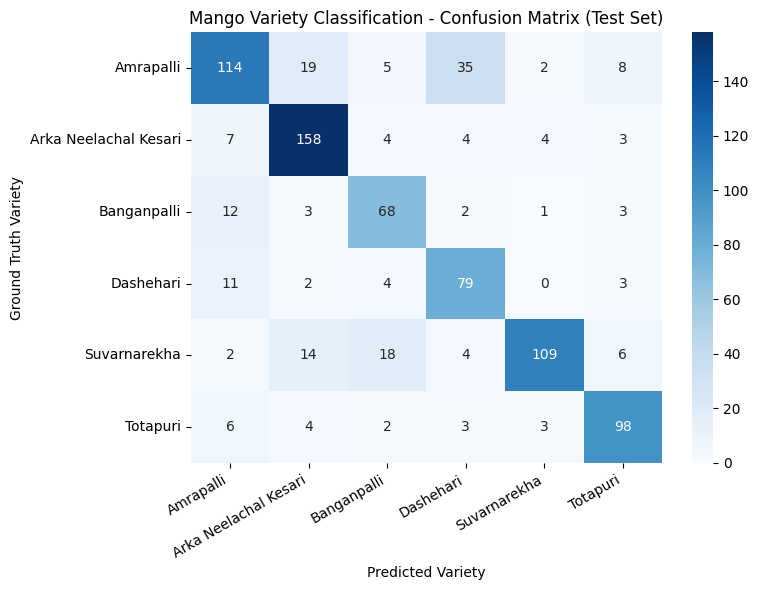

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("=" * 60)
print("EVALUATING BEST MODEL ON HELD-OUT TEST SET")
print("=" * 60)

# Load best checkpoint weights
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Confusion Matrix Heatmap
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Mango Variety Classification - Confusion Matrix (Test Set)")
plt.xlabel("Predicted Variety")
plt.ylabel("Ground Truth Variety")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()